<a href="https://colab.research.google.com/github/rezar362/Portfolio/blob/main/soccer_strategy/soccer_strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# Block 0: Setup — run this every time you open Colab
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/soccer_strategy'
import os
os.makedirs(DRIVE_PATH, exist_ok=True)

!pip install statsbombpy torch torch-geometric scikit-learn xgboost matplotlib pandas numpy -q

import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

print(f"✅ Drive mounted: {DRIVE_PATH}")
print(f"✅ Files on Drive: {os.listdir(DRIVE_PATH) if os.path.exists(DRIVE_PATH) else 'empty'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 962.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 8.1 MB/s eta 0:00:00
✅ Drive mounted: /content/drive/MyDrive/soccer_strategy
✅ Files on Drive: ['wc2022_passes.pkl', 'pass_graphs.pkl', 'pass_network_sample.png', 'gnn_model.pt', 'training_curve.png', 'gnn_results.pkl', 'pass_optimization.png', 'zone_graph.pkl', 'team_zone_graphs.pkl', 'optimal_paths.pkl', 'optimal_routes_top8.png', 'optimal_routes_all32.png', 'iran_vs_argentina.png', 'iran_vs_argentina_corrected.png', 'iran_vs_usa.png', 'iran_vs_arg_usa_comparison.png', 'iran_all_zones_comparison.png', 'iran_6x2_comparison.png', 'iran_hard_blocked.png', 'wc2022_all_events.pkl', 'shot_sequences.pkl']


In [10]:
# Block 1: Download all World Cup 2022 pass events and save to Drive

from statsbombpy import sb

DATA_FILE = f'{DRIVE_PATH}/wc2022_passes.pkl'

if os.path.exists(DATA_FILE):
    print("📂 Loading from Drive...")
    with open(DATA_FILE, 'rb') as f:
        saved = pickle.load(f)
    passes_df  = saved['passes_df']
    matches_df = saved['matches_df']
else:
    competitions = sb.competitions()
    wc2022 = competitions[
        (competitions['competition_name'] == 'FIFA World Cup') &
        (competitions['season_name'] == '2022')
    ]
    COMPETITION_ID = int(wc2022['competition_id'].iloc[0])
    SEASON_ID      = int(wc2022['season_id'].iloc[0])
    matches_df     = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
    print(f"✅ {len(matches_df)} matches found")

    all_passes = []
    for i, (_, match) in enumerate(matches_df.iterrows()):
        try:
            events = sb.events(match_id=match['match_id'])
            passes = events[events['type'] == 'Pass'].copy()
            passes['match_id']   = match['match_id']
            passes['home_team']  = match['home_team']
            passes['away_team']  = match['away_team']
            all_passes.append(passes)
            if (i+1) % 10 == 0:
                print(f"   {i+1}/64 loaded...")
        except:
            pass

    passes_df = pd.concat(all_passes, ignore_index=True)
    with open(DATA_FILE, 'wb') as f:
        pickle.dump({'passes_df': passes_df, 'matches_df': matches_df}, f)

print(f"✅ Passes: {len(passes_df):,} | Matches: {len(matches_df)}")

📂 Loading from Drive...
✅ Passes: 68,515 | Matches: 64


In [11]:
# Block 2: Download all events (passes + shots) needed for ML training

EVENTS_FILE = f'{DRIVE_PATH}/wc2022_all_events.pkl'

if os.path.exists(EVENTS_FILE):
    print("📂 Loading events from Drive...")
    with open(EVENTS_FILE, 'rb') as f:
        all_events = pickle.load(f)
else:
    print("⬇️  Downloading all events...")
    event_list = []
    for i, (_, match) in enumerate(matches_df.iterrows()):
        try:
            events = sb.events(match_id=match['match_id'])
            events['match_id'] = match['match_id']
            event_list.append(events)
            if (i+1) % 10 == 0:
                print(f"   {i+1}/64 loaded...")
        except:
            pass
    all_events = pd.concat(event_list, ignore_index=True)
    with open(EVENTS_FILE, 'wb') as f:
        pickle.dump(all_events, f)

print(f"✅ Total events: {len(all_events):,}")
print(f"   Types: {all_events['type'].value_counts().head(5).to_dict()}")

📂 Loading events from Drive...
✅ Total events: 234,652
   Types: {'Pass': 68515, 'Ball Receipt*': 63715, 'Carry': 53764, 'Pressure': 16553, 'Ball Recovery': 5821}


In [12]:
# Block 3: Define zones, compute per-team defensive pressure profiles

def extract_coords(loc):
    if isinstance(loc, list) and len(loc) == 2:
        return loc[0], loc[1]
    return None, None

def get_zone(x, y):
    if x is None or y is None or pd.isna(x) or pd.isna(y):
        return None
    if x >= 115 and 30 <= y <= 50:
        return 6
    third = 0 if x < 40 else (1 if x < 80 else 2)
    side  = 0 if y < 40 else 1
    return third * 2 + side

ZONES = {
    0: {'name': 'Def (Right)'},
    1: {'name': 'Def (Left)'},
    2: {'name': 'Mid (Right)'},
    3: {'name': 'Mid (Left)'},
    4: {'name': 'Att (Right)'},
    5: {'name': 'Att (Left)'},
    6: {'name': 'GOAL'},
}

ZONE_CENTERS = {
    0: (20,20), 1: (20,60),
    2: (60,20), 3: (60,60),
    4: (100,20), 5: (100,60),
    6: (121,40)
}

# Add zone to passes
passes_df['x_start'] = passes_df['location'].apply(lambda l: extract_coords(l)[0])
passes_df['y_start'] = passes_df['location'].apply(lambda l: extract_coords(l)[1])
passes_df['x_end']   = passes_df['pass_end_location'].apply(lambda l: extract_coords(l)[0])
passes_df['y_end']   = passes_df['pass_end_location'].apply(lambda l: extract_coords(l)[1])
passes_df = passes_df.dropna(subset=['x_start','y_start','x_end','y_end'])
passes_df['zone_start'] = passes_df.apply(lambda r: get_zone(r['x_start'], r['y_start']), axis=1)
passes_df['zone_end']   = passes_df.apply(lambda r: get_zone(r['x_end'],   r['y_end']),   axis=1)
passes_df = passes_df.dropna(subset=['zone_start','zone_end'])
passes_df['zone_start'] = passes_df['zone_start'].astype(int)
passes_df['zone_end']   = passes_df['zone_end'].astype(int)
passes_df['success']    = passes_df['pass_outcome'].isna().astype(int)
passes_df['pressure']   = passes_df.get('under_pressure', pd.Series(False, index=passes_df.index)).fillna(False).astype(float)

# Compute defensive profile per team
DEFENSE_FILE = f'{DRIVE_PATH}/defense_profiles.pkl'

if os.path.exists(DEFENSE_FILE):
    with open(DEFENSE_FILE, 'rb') as f:
        defense_profiles = pickle.load(f)
else:
    teams = passes_df['team'].unique()
    defense_profiles = {}
    for team in teams:
        match_ids = passes_df[passes_df['team'] == team]['match_id'].unique()
        opp = passes_df[
            (passes_df['match_id'].isin(match_ids)) &
            (passes_df['team'] != team)
        ].copy()
        profile = opp.groupby('zone_start').agg(
            failure_rate=('success', lambda x: 1 - x.mean())
        )['failure_rate'].to_dict()
        defense_profiles[team] = profile

    with open(DEFENSE_FILE, 'wb') as f:
        pickle.dump(defense_profiles, f)

print(f"✅ Defense profiles: {len(defense_profiles)} teams")
print(f"✅ Zone setup complete")

✅ Defense profiles: 32 teams
✅ Zone setup complete


In [13]:
# Block 4: Extract shot sequences and build training dataset for XGBoost

all_events['x'] = all_events['location'].apply(lambda l: extract_coords(l)[0])
all_events['y'] = all_events['location'].apply(lambda l: extract_coords(l)[1])
all_events['zone'] = all_events.apply(lambda r: get_zone(r['x'], r['y']), axis=1)

SEQ_FILE = f'{DRIVE_PATH}/ml_training_data.pkl'

if os.path.exists(SEQ_FILE):
    print("📂 Loading training data from Drive...")
    with open(SEQ_FILE, 'rb') as f:
        training_df = pickle.load(f)
else:
    print("Building training dataset...")
    samples = []

    for match_id in all_events['match_id'].unique():
        match_ev = all_events[all_events['match_id'] == match_id].sort_values('index')

        for team in match_ev['team'].unique():
            team_ev = match_ev[match_ev['team'] == team].reset_index(drop=True)
            shot_indices = team_ev[team_ev['type'] == 'Shot'].index.tolist()
            opp_team = [t for t in match_ev['team'].unique() if t != team]
            opp_team = opp_team[0] if opp_team else None

            if opp_team is None or opp_team not in defense_profiles:
                continue

            opp_defense = defense_profiles[opp_team]

            for shot_idx in shot_indices:
                lookback = min(shot_idx, 5)
                seq_events = []

                for i in range(shot_idx - lookback, shot_idx + 1):
                    ev = team_ev.iloc[i]
                    if ev['type'] in ['Pass', 'Shot'] and ev['zone'] is not None:
                        seq_events.append(ev)

                # Build samples from sequence
                for i in range(len(seq_events) - 1):
                    current_zone = seq_events[i]['zone']
                    next_zone    = seq_events[i+1]['zone']

                    if pd.isna(current_zone) or pd.isna(next_zone):
                        continue

                    # Features: current zone + opponent pressure in all 6 zones
                    features = {
                        'current_zone': int(current_zone),
                        'team'        : team,
                        'opponent'    : opp_team,
                    }
                    for z in range(6):
                        features[f'opp_pressure_z{z}'] = opp_defense.get(z, 0.2)

                    features['next_zone'] = int(next_zone)
                    samples.append(features)

    training_df = pd.DataFrame(samples)
    with open(SEQ_FILE, 'wb') as f:
        pickle.dump(training_df, f)

print(f"✅ Training samples: {len(training_df):,}")
print(f"✅ Features: {[c for c in training_df.columns if c != 'next_zone']}")
print(f"\n── Next Zone Distribution ──")
print(training_df['next_zone'].value_counts().sort_index())

Building training dataset...
✅ Training samples: 2,124
✅ Features: ['current_zone', 'team', 'opponent', 'opp_pressure_z0', 'opp_pressure_z1', 'opp_pressure_z2', 'opp_pressure_z3', 'opp_pressure_z4', 'opp_pressure_z5']

── Next Zone Distribution ──
next_zone
0       3
1       3
2      18
3      14
4     940
5    1060
6      86
Name: count, dtype: int64


In [14]:
# Block 5: Train XGBoost to predict next optimal zone

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import joblib

MODEL_FILE = f'{DRIVE_PATH}/xgb_pass_model.pkl'

FEATURE_COLS = ['current_zone'] + [f'opp_pressure_z{z}' for z in range(6)]
TARGET_COL   = 'next_zone'

X = training_df[FEATURE_COLS].values
y = training_df[TARGET_COL].values

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"✅ Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"✅ Classes: {le.classes_}")

if os.path.exists(MODEL_FILE):
    print("📂 Loading model from Drive...")
    with open(MODEL_FILE, 'rb') as f:
        saved_model = pickle.load(f)
    model = saved_model['model']
    le    = saved_model['le']
else:
    print("Training XGBoost...")
    model = XGBClassifier(
        n_estimators    = 300,
        max_depth       = 6,
        learning_rate   = 0.05,
        subsample       = 0.8,
        colsample_bytree= 0.8,
        use_label_encoder=False,
        eval_metric     = 'mlogloss',
        random_state    = 42,
        n_jobs          = -1
    )
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=50)

    with open(MODEL_FILE, 'wb') as f:
        pickle.dump({'model': model, 'le': le}, f)

y_pred = model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
print(f"\n✅ Test Accuracy: {acc:.3f}")
print(f"\n── Classification Report ──")
print(classification_report(y_test, y_pred,
      target_names=[ZONES[int(c)]['name'] for c in le.classes_]))

✅ Train: 1,699 | Test: 425
✅ Classes: [0 1 2 3 4 5 6]
Training XGBoost...
[0]	validation_0-mlogloss:0.92721
[50]	validation_0-mlogloss:0.86665
[100]	validation_0-mlogloss:0.88345
[150]	validation_0-mlogloss:0.90063
[200]	validation_0-mlogloss:0.91525
[250]	validation_0-mlogloss:0.92657
[299]	validation_0-mlogloss:0.94193

✅ Test Accuracy: 0.656

── Classification Report ──
              precision    recall  f1-score   support

 Def (Right)       0.00      0.00      0.00         1
  Def (Left)       0.00      0.00      0.00         0
 Mid (Right)       0.00      0.00      0.00         4
  Mid (Left)       0.00      0.00      0.00         3
 Att (Right)       0.64      0.68      0.66       188
  Att (Left)       0.67      0.72      0.69       212
        GOAL       0.00      0.00      0.00        17

    accuracy                           0.66       425
   macro avg       0.19      0.20      0.19       425
weighted avg       0.62      0.66      0.64       425



In [15]:
# Block 6: Predict optimal passing sequence for any team vs any opponent
# Greedy path: at each zone pick next zone with highest probability toward goal

import matplotlib.pyplot as plt
import matplotlib.patches as patches

def predict_optimal_path(attacking_team, defending_team, start_zone,
                          max_steps=6, top_k=3):
    """Predict optimal passing sequence using XGBoost."""
    opp_defense = defense_profiles.get(defending_team, {})
    opp_features = [opp_defense.get(z, 0.2) for z in range(6)]

    def get_next_zone_probs(current_zone):
        features = np.array([[current_zone] + opp_features])
        probs    = model.predict_proba(features)[0]
        # Map back to zone labels
        zone_probs = {int(le.classes_[i]): float(probs[i])
                      for i in range(len(le.classes_))}
        return zone_probs

    # Find top_k paths using beam search
    # State: (neg_log_prob, path)
    import heapq
    beam = [(0.0, [start_zone])]
    completed = []

    while beam and len(completed) < top_k:
        cost, path = heapq.heappop(beam)
        current = path[-1]

        if current == 6:
            completed.append((cost, path))
            continue
        if len(path) > max_steps:
            continue

        probs = get_next_zone_probs(current)
        # Sort by probability descending
        for zone, prob in sorted(probs.items(), key=lambda x: -x[1])[:3]:
            if zone not in path or zone == 6:
                new_cost = cost - np.log(prob + 1e-8)
                heapq.heappush(beam, (new_cost, path + [zone]))

    return completed

# ── Test prediction ───────────────────────────────────────────
def print_paths(paths, attacking, defending, start):
    print(f"\n── {attacking} vs {defending} — from {ZONES[start]['name']} ──")
    for rank, (cost, path) in enumerate(paths, 1):
        zone_names = ' → '.join([ZONES[z]['name'] for z in path])
        print(f"   Path {rank}: {zone_names} (score={cost:.2f})")

for start in range(6):
    paths = predict_optimal_path('Iran', 'Argentina', start_zone=start)
    print_paths(paths, 'Iran', 'Argentina', start)

print("\n" + "="*60)

for start in range(6):
    paths = predict_optimal_path('Iran', 'United States', start_zone=start)
    print_paths(paths, 'Iran', 'USA', start)


── Iran vs Argentina — from Def (Right) ──
   Path 1: Def (Right) → Att (Left) → GOAL (score=4.92)
   Path 2: Def (Right) → Att (Right) → Att (Left) → GOAL (score=5.02)
   Path 3: Def (Right) → Att (Right) → GOAL (score=5.16)

── Iran vs Argentina — from Def (Left) ──
   Path 1: Def (Left) → Att (Left) → GOAL (score=3.85)
   Path 2: Def (Left) → Att (Right) → Att (Left) → GOAL (score=6.14)
   Path 3: Def (Left) → Att (Right) → GOAL (score=6.28)

── Iran vs Argentina — from Mid (Right) ──
   Path 1: Mid (Right) → Att (Left) → GOAL (score=4.05)
   Path 2: Mid (Right) → Att (Right) → Att (Left) → GOAL (score=5.38)
   Path 3: Mid (Right) → Att (Right) → GOAL (score=5.53)

── Iran vs Argentina — from Mid (Left) ──
   Path 1: Mid (Left) → Att (Left) → GOAL (score=3.75)
   Path 2: Mid (Left) → Att (Right) → Att (Left) → GOAL (score=5.81)
   Path 3: Mid (Left) → Att (Right) → GOAL (score=5.95)

── Iran vs Argentina — from Att (Right) ──
   Path 1: Att (Right) → Att (Left) → GOAL (score=4.69)


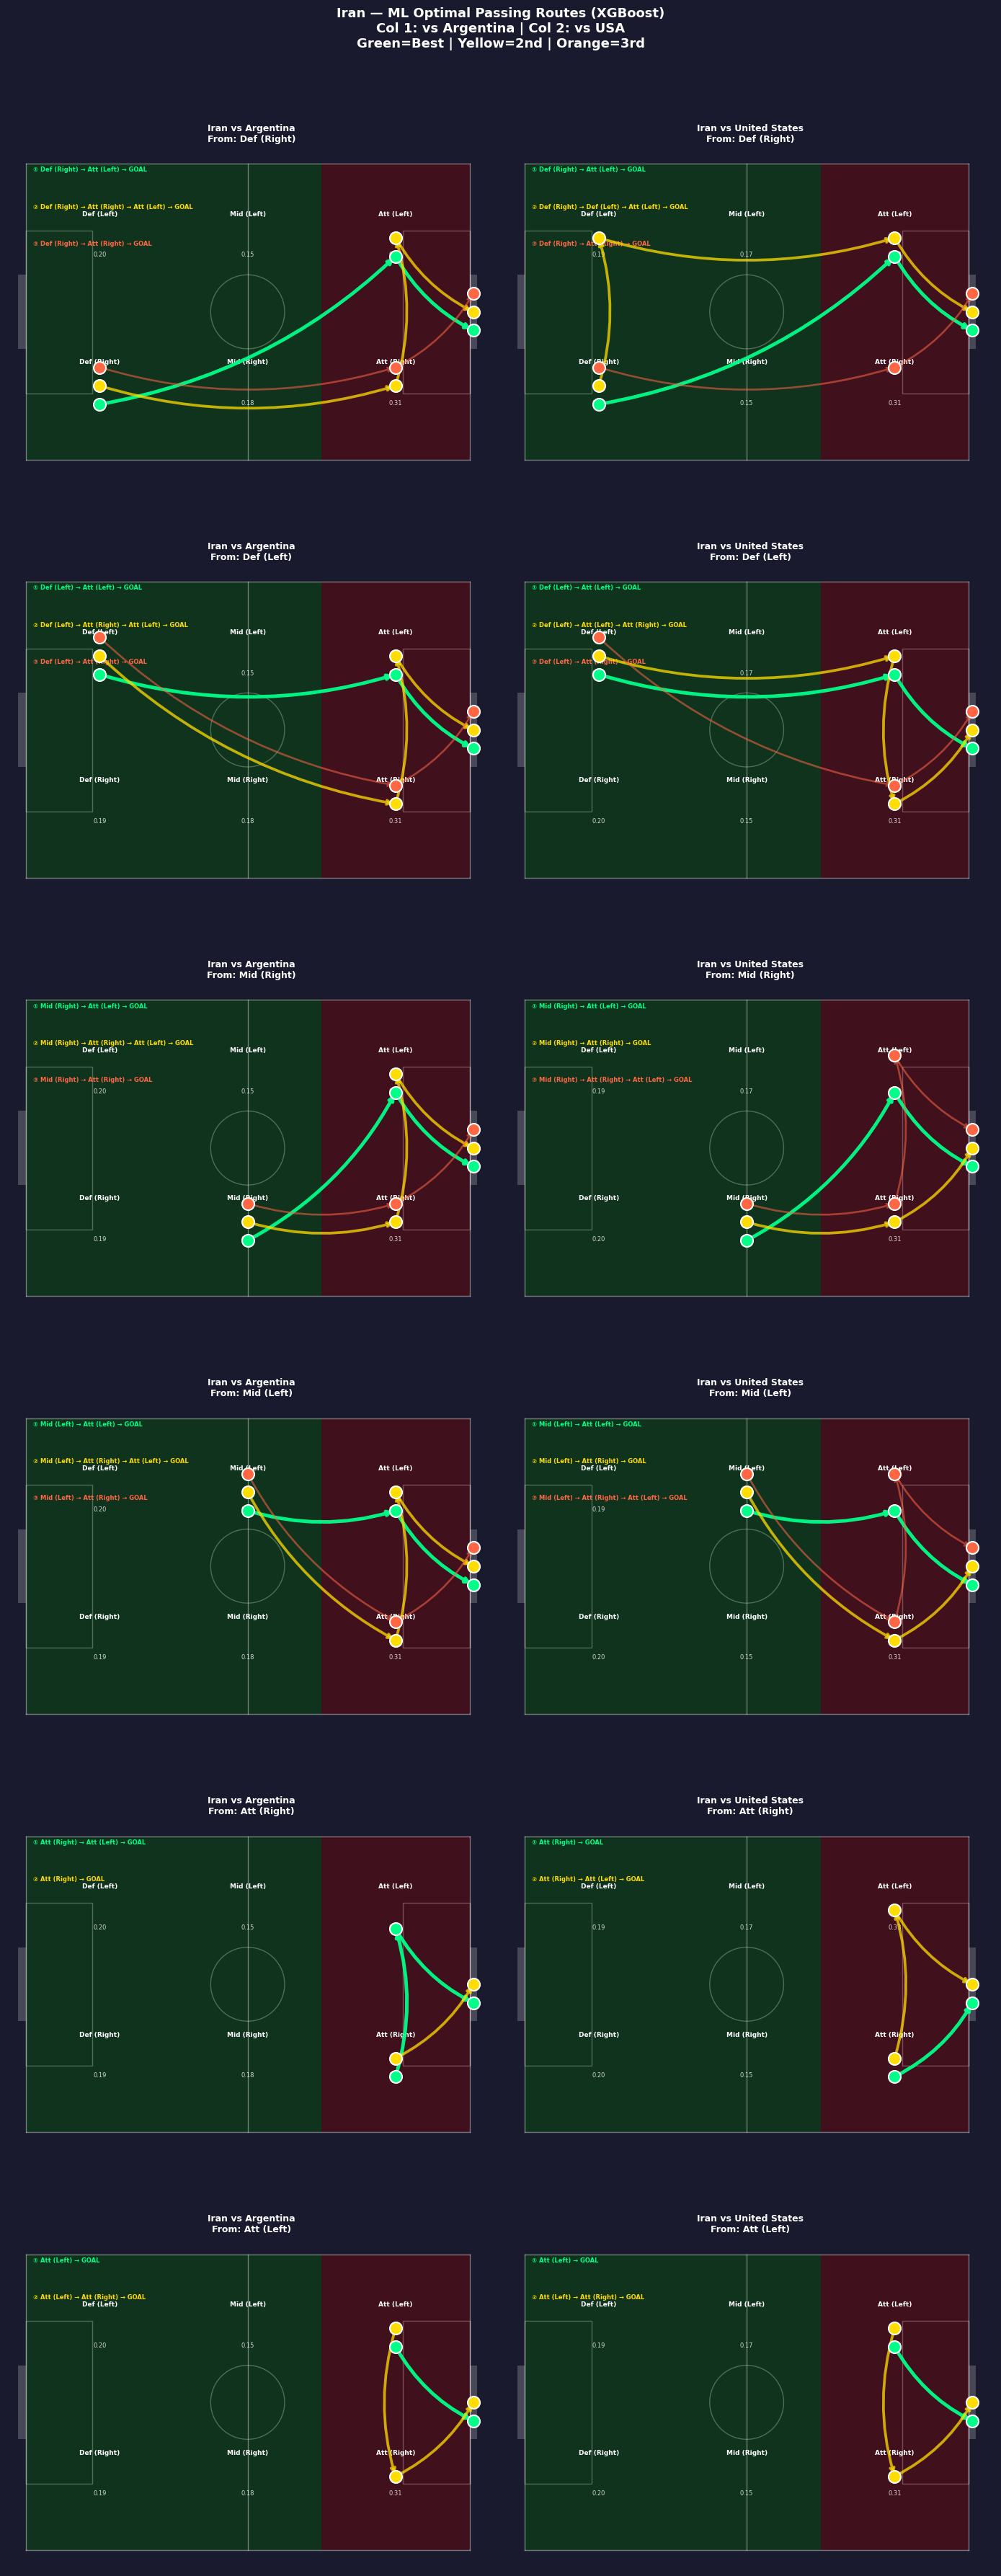

✅ ML visualization saved


In [16]:
# Block 7: Visualize Iran vs Argentina vs USA — 6 rows x 2 cols

PATH_COLORS = ['#00ff88', '#ffdd00', '#ff6644']

def draw_pitch(ax, bg='#2d5a1b'):
    ax.set_facecolor(bg)
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    ax.plot([0,120],[0,0],'w',alpha=0.4,lw=1)
    ax.plot([0,120],[80,80],'w',alpha=0.4,lw=1)
    ax.plot([0,0],[0,80],'w',alpha=0.4,lw=1)
    ax.plot([120,120],[0,80],'w',alpha=0.4,lw=1)
    ax.plot([60,60],[0,80],'w',alpha=0.4,lw=1)
    circle = plt.Circle((60,40),10,color='white',fill=False,alpha=0.4,lw=1)
    ax.add_patch(circle)
    ax.add_patch(patches.Rectangle((0,18),18,44,fill=False,edgecolor='white',alpha=0.4,lw=1))
    ax.add_patch(patches.Rectangle((102,18),18,44,fill=False,edgecolor='white',alpha=0.4,lw=1))
    ax.add_patch(patches.Rectangle((-2,30),2,20,fill=True,facecolor='white',alpha=0.2))
    ax.add_patch(patches.Rectangle((120,30),2,20,fill=True,facecolor='white',alpha=0.2))
    ax.set_xlim(-5,127); ax.set_ylim(-5,85)
    ax.set_aspect('equal'); ax.axis('off')

def draw_zones_pressure(ax, defense_dict, block_threshold=0.25):
    zone_rects = {
        0:(0,0,40,40), 1:(0,40,40,40),
        2:(40,0,40,40), 3:(40,40,40,40),
        4:(80,0,40,40), 5:(80,40,40,40),
    }
    for z, (x,y,w,h) in zone_rects.items():
        pressure = defense_dict.get(z, 0.2)
        color    = '#8B0000' if pressure > block_threshold else '#006400'
        ax.add_patch(patches.Rectangle((x,y),w,h,
                     facecolor=color, alpha=0.35, zorder=1))
        cx,cy = ZONE_CENTERS[z]
        ax.text(cx, cy+6, ZONES[z]['name'],
                ha='center', fontsize=6.5, color='white',
                fontweight='bold')
        ax.text(cx, cy-5, f'{pressure:.2f}',
                ha='center', fontsize=6, color='white', alpha=0.8)

def draw_path(ax, path, color, lw=3, alpha=0.9, offset=0):
    for i in range(len(path)-1):
        x0,y0 = ZONE_CENTERS[path[i]]
        x1,y1 = ZONE_CENTERS[path[i+1]]
        y0+=offset; y1+=offset
        ax.annotate('', xy=(x1,y1), xytext=(x0,y0),
                    arrowprops=dict(arrowstyle='->',color=color,
                                   lw=lw,alpha=alpha,
                                   connectionstyle='arc3,rad=0.15'),
                    zorder=5)
    for z in path:
        cx,cy = ZONE_CENTERS[z]
        cy+=offset
        ax.scatter(cx,cy,s=150,color=color,zorder=6,
                   edgecolors='white',linewidths=1.5)

OPPONENTS = {
    'Argentina'    : defense_profiles.get('Argentina', {}),
    'United States': defense_profiles.get('United States', {}),
}

fig, axes = plt.subplots(6, 2, figsize=(14, 36))

for row, start in enumerate(range(6)):
    for col, (opponent, defense_dict) in enumerate(OPPONENTS.items()):
        ax = axes[row, col]
        draw_pitch(ax)
        draw_zones_pressure(ax, defense_dict)

        paths   = predict_optimal_path('Iran', opponent, start_zone=start)
        offsets = [-5, 0, 5]

        for rank, (cost, path) in enumerate(paths[:3]):
            draw_path(ax, path, color=PATH_COLORS[rank],
                      lw=3.5-rank*0.8, alpha=0.95-rank*0.2,
                      offset=offsets[rank])
            zone_names = ' → '.join([ZONES[z]['name'] for z in path])
            ax.text(2, 78-rank*10,
                    f'{"①②③"[rank]} {zone_names}',
                    fontsize=6, color=PATH_COLORS[rank], fontweight='bold')

        ax.set_title(f'Iran vs {opponent}\nFrom: {ZONES[start]["name"]}',
                     fontsize=9, fontweight='bold', color='white', pad=4)

plt.suptitle('Iran — ML Optimal Passing Routes (XGBoost)\n'
             'Col 1: vs Argentina | Col 2: vs USA\n'
             'Green=Best | Yellow=2nd | Orange=3rd',
             fontsize=13, fontweight='bold', color='white', y=1.01)
fig.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/iran_ml_optimal.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("✅ ML visualization saved")